<a href="https://colab.research.google.com/github/ANDERSONR7/tecemer-lab1/blob/main/Ejercicio_04a_RNN_NLP_Analisis_Sentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4a — Redes Neuronales Recurrentes (RNN): NLP — Análisis de Sentimientos
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Usa el dataset público **IMDB** (reseñas de películas en inglés, etiquetadas como positivas/negativas), descargado automáticamente con la librería `datasets` de Hugging Face.

**Objetivo:** entender cómo una RNN (LSTM) procesa texto **como una secuencia** (a diferencia de un modelo de "bolsa de palabras" que ignora el orden), y recorrer el flujo completo de NLP: tokenización, vocabulario, padding, embeddings, entrenamiento y evaluación.

Framework: **PyTorch** (en el Notebook 4b volvemos a TensorFlow/Keras, para practicar ambos, tal como se usan en la industria).

## 0. Configuración inicial

In [ ]:
!pip install -q datasets

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

from datasets import load_dataset

sns.set_style("whitegrid")
torch.manual_seed(42)
np.random.seed(42)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, " | Dispositivo:", dispositivo)

PyTorch: 2.11.0+cu130  | Dispositivo: cuda


## 1. Cargar y explorar los datos

Para que el entrenamiento sea rápido en Colab (CPU), usamos un subconjunto del dataset completo.

In [2]:
dataset = load_dataset("stanfordnlp/imdb")

N_TRAIN, N_TEST = 4000, 1000
rng = np.random.default_rng(42)

idx_train = rng.choice(len(dataset["train"]), size=N_TRAIN, replace=False)
idx_test = rng.choice(len(dataset["test"]), size=N_TEST, replace=False)

textos_train = [dataset["train"][int(i)]["text"] for i in idx_train]
etiquetas_train = [dataset["train"][int(i)]["label"] for i in idx_train]
textos_test = [dataset["test"][int(i)]["text"] for i in idx_test]
etiquetas_test = [dataset["test"][int(i)]["label"] for i in idx_test]

print(f"Entrenamiento: {len(textos_train)} reseñas | Prueba: {len(textos_test)} reseñas")
print("\nEjemplo (positiva)" if etiquetas_train[0] == 1 else "\nEjemplo (negativa)")
print(textos_train[0][:400], "...")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Entrenamiento: 4000 reseñas | Prueba: 1000 reseñas

Ejemplo (negativa)
I'm actually watching this film as I write this . . . If the following comments "prove my lack of development as a true, artistic film maker", then so be it . . .<br /><br />But . . . I thought (am still thinking as I'm presently viewing) that this film . . . to put it mildly, is very, very overrated. Again, very.<br /><br />It looks like a really, really bad student film done by a someone with be ...


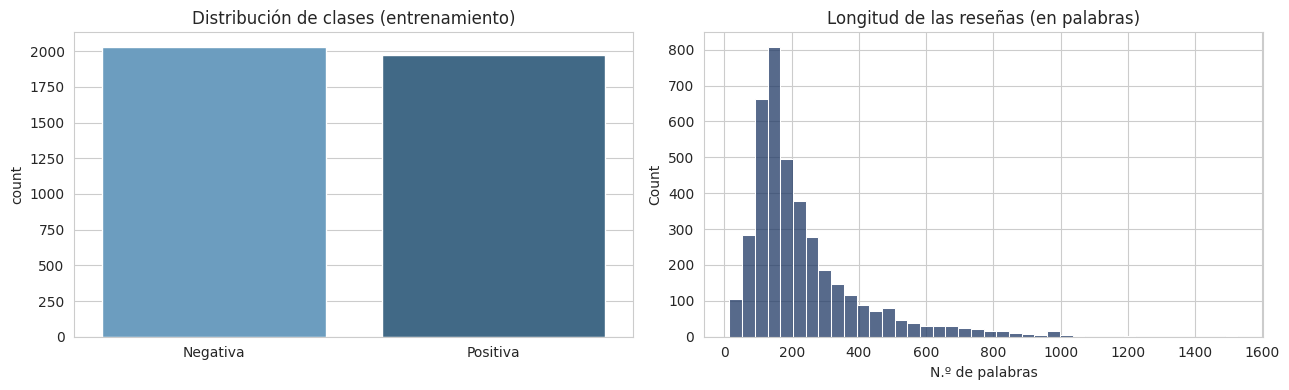

Longitud promedio: 233 palabras | Mediana: 176


In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=[("Positiva" if e == 1 else "Negativa") for e in etiquetas_train], ax=ejes[0],
              hue=[("Positiva" if e == 1 else "Negativa") for e in etiquetas_train], palette="Blues_d", legend=False)
ejes[0].set_title("Distribución de clases (entrenamiento)")

longitudes = [len(t.split()) for t in textos_train]
sns.histplot(longitudes, bins=40, ax=ejes[1], color="#1F3864")
ejes[1].set_title("Longitud de las reseñas (en palabras)")
ejes[1].set_xlabel("N.º de palabras")
plt.tight_layout()
plt.show()

print(f"Longitud promedio: {np.mean(longitudes):.0f} palabras | Mediana: {np.median(longitudes):.0f}")

## 2. Preprocesamiento de texto: tokenización y vocabulario

Una red neuronal no puede procesar texto directamente — necesitamos convertir cada palabra en un número entero. Pasos:
1. **Tokenizar**: limpiar HTML/puntuación y separar en palabras (tokens).
2. **Construir un vocabulario**: quedarnos con las N palabras más frecuentes (las palabras raras aportan poco y aumentan mucho el tamaño del modelo).
3. **Convertir cada reseña en una secuencia de índices**, con tokens especiales `<PAD>` (relleno) y `<UNK>` (palabra desconocida).

In [4]:
def tokenizar(texto):
    texto = re.sub(r"<br\s*/?>", " ", texto)          # quitar etiquetas HTML propias de IMDB
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto.lower())  # quitar puntuación y números
    return texto.split()

TAM_VOCABULARIO = 8000
contador = Counter()
for texto in textos_train:
    contador.update(tokenizar(texto))

palabras_frecuentes = [palabra for palabra, _ in contador.most_common(TAM_VOCABULARIO - 2)]
vocabulario = {"<PAD>": 0, "<UNK>": 1}
vocabulario.update({palabra: i + 2 for i, palabra in enumerate(palabras_frecuentes)})

print(f"Tamaño del vocabulario: {len(vocabulario)}")
print("Palabras más frecuentes:", palabras_frecuentes[:15])

Tamaño del vocabulario: 8000
Palabras más frecuentes: ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this', 'that', 's', 'was', 'as', 'with']


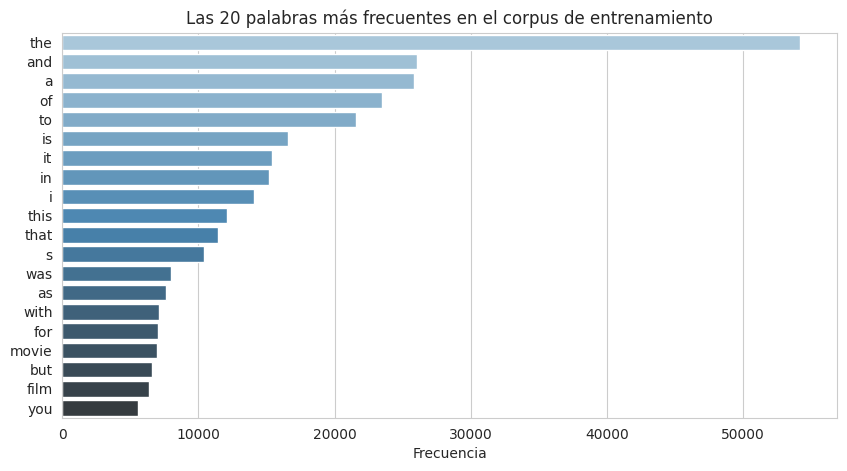

In [5]:
top20 = contador.most_common(20)
palabras, frecuencias = zip(*top20)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(frecuencias), y=list(palabras), hue=list(palabras), palette="Blues_d", legend=False)
plt.title("Las 20 palabras más frecuentes en el corpus de entrenamiento")
plt.xlabel("Frecuencia")
plt.show()

**Nota:** es normal que dominen palabras funcionales ("the", "and", "of"...) — no aportan mucha información de sentimiento por sí solas, pero el modelo aprenderá a darles poco peso frente a palabras como "great" o "terrible".

## 3. Convertir texto a secuencias numéricas (con padding)

In [6]:
LONGITUD_MAXIMA = 200

def texto_a_secuencia(texto, vocabulario, longitud_maxima):
    tokens = tokenizar(texto)
    indices = [vocabulario.get(t, vocabulario["<UNK>"]) for t in tokens][:longitud_maxima]
    indices += [vocabulario["<PAD>"]] * (longitud_maxima - len(indices))
    return indices

X_train = np.array([texto_a_secuencia(t, vocabulario, LONGITUD_MAXIMA) for t in textos_train])
X_test = np.array([texto_a_secuencia(t, vocabulario, LONGITUD_MAXIMA) for t in textos_test])
y_train = np.array(etiquetas_train, dtype="float32")
y_test = np.array(etiquetas_test, dtype="float32")

print("Forma de X_train:", X_train.shape)
print("\nEjemplo de secuencia (primeros 20 índices):", X_train[0][:20])

Forma de X_train: (4000, 200)

Ejemplo de secuencia (primeros 20 índices): [  10  142  159  158   11   20   15   10  893   11   45    2 1052  671
 1831   59  555    5  929   15]


## 4. Preparar `Dataset` y `DataLoader` de PyTorch

In [7]:
class ReseñasDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset_train = ReseñasDataset(X_train, y_train)
dataset_test = ReseñasDataset(X_test, y_test)

loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

print("Lotes de entrenamiento:", len(loader_train))

Lotes de entrenamiento: 125


## 5. Construir la LSTM

- **`Embedding`**: convierte cada índice de palabra en un vector denso entrenable (aprende qué palabras son "parecidas" en significado/uso).
- **`LSTM`**: procesa la secuencia de embeddings palabra por palabra, manteniendo una "memoria" (estado oculto) que se actualiza en cada paso — así SÍ captura el orden de las palabras.
- **`Linear`**: capa final que transforma el último estado oculto en una probabilidad de sentimiento positivo.

In [8]:
class LSTMSentimiento(nn.Module):
    def __init__(self, tam_vocabulario, dim_embedding=64, unidades_lstm=64):
        super().__init__()
        self.embedding = nn.Embedding(tam_vocabulario, dim_embedding, padding_idx=0)
        self.lstm = nn.LSTM(dim_embedding, unidades_lstm, batch_first=True)
        self.salida = nn.Linear(unidades_lstm, 1)

    def forward(self, x):
        embebido = self.embedding(x)                       # (lote, longitud, dim_embedding)
        _, (h_final, _) = self.lstm(embebido)               # h_final: (1, lote, unidades_lstm)
        logit = self.salida(h_final.squeeze(0))             # (lote, 1)
        return logit.squeeze(1)

modelo = LSTMSentimiento(tam_vocabulario=len(vocabulario)).to(dispositivo)
print(modelo)
n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"\nParámetros totales: {n_parametros:,}")

LSTMSentimiento(
  (embedding): Embedding(8000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (salida): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales: 545,345


## 6. Entrenar (bucle manual)

A diferencia de Keras (`.fit()`), en PyTorch el bucle de entrenamiento se escribe explícitamente — esto hace visible cada paso: propagación hacia adelante, cálculo de pérdida, retropropagación y actualización de pesos.

In [26]:
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

def evaluar(modelo, loader):
    modelo.eval()
    correctos, total, perdida_total = 0, 0, 0.0
    with torch.no_grad():
        for X_lote, y_lote in loader:
            X_lote, y_lote = X_lote.to(dispositivo), y_lote.to(dispositivo)
            logits = modelo(X_lote)
            perdida_total += funcion_perdida(logits, y_lote).item() * len(y_lote)
            predicciones = (torch.sigmoid(logits) > 0.5).float()
            correctos += (predicciones == y_lote).sum().item()
            total += len(y_lote)
    return perdida_total / total, correctos / total

N_EPOCAS = 60

historial = {"perdida_train": [], "precision_train": [], "perdida_val": [], "precision_val": []}

for epoca in range(N_EPOCAS):
    modelo.train()
    for X_lote, y_lote in loader_train:
        X_lote, y_lote = X_lote.to(dispositivo), y_lote.to(dispositivo)
        optimizador.zero_grad()
        logits = modelo(X_lote)
        perdida = funcion_perdida(logits, y_lote)
        perdida.backward()
        optimizador.step()

    perdida_train, precision_train = evaluar(modelo, loader_train)
    perdida_val, precision_val = evaluar(modelo, loader_test)
    historial["perdida_train"].append(perdida_train)
    historial["precision_train"].append(precision_train)
    historial["perdida_val"].append(perdida_val)
    historial["precision_val"].append(precision_val)
    print(f"Época {epoca+1}/{N_EPOCAS} — pérdida_train: {perdida_train:.3f}  precision_train: {precision_train:.3f}  "
          f"pérdida_val: {perdida_val:.3f}  precision_val: {precision_val:.3f}")

Época 1/60 — pérdida_train: 0.091  precision_train: 0.993  pérdida_val: 3.894  precision_val: 0.716
Época 2/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.681  precision_val: 0.736
Época 3/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.677  precision_val: 0.731
Época 4/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.661  precision_val: 0.734
Época 5/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.655  precision_val: 0.735
Época 6/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.647  precision_val: 0.734
Época 7/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.638  precision_val: 0.733
Época 8/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.635  precision_val: 0.734
Época 9/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.633  precision_val: 0.731
Época 10/60 — pérdida_train: 0.000  precision_train: 1.000  pérdida_val: 2.630  precision_val: 0.730

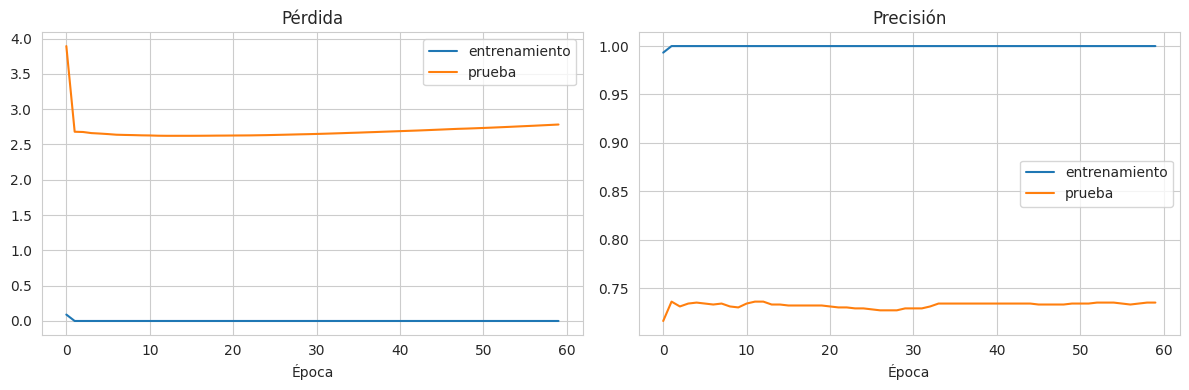

In [27]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(historial["perdida_train"], label="entrenamiento")
ejes[0].plot(historial["perdida_val"], label="prueba")
ejes[0].set_title("Pérdida"); ejes[0].set_xlabel("Época"); ejes[0].legend()
ejes[1].plot(historial["precision_train"], label="entrenamiento")
ejes[1].plot(historial["precision_val"], label="prueba")
ejes[1].set_title("Precisión"); ejes[1].set_xlabel("Época"); ejes[1].legend()
plt.tight_layout()
plt.show()

## 7. Evaluación: matriz de confusión

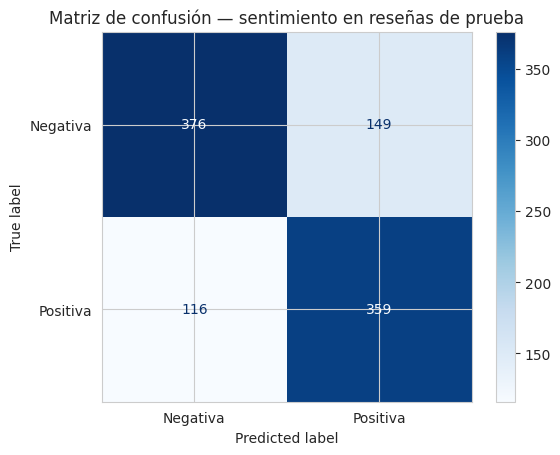

In [28]:
modelo.eval()
todas_predicciones, todas_reales = [], []
with torch.no_grad():
    for X_lote, y_lote in loader_test:
        logits = modelo(X_lote.to(dispositivo))
        predicciones = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
        todas_predicciones.extend(predicciones)
        todas_reales.extend(y_lote.numpy())

ConfusionMatrixDisplay(confusion_matrix(todas_reales, todas_predicciones),
                        display_labels=["Negativa", "Positiva"]).plot(cmap="Blues")
plt.title("Matriz de confusión — sentimiento en reseñas de prueba")
plt.show()

## 8. Visualizar el espacio de embeddings aprendido

Cada palabra del vocabulario ahora tiene un vector de 64 dimensiones. Con PCA lo reducimos a 2 dimensiones para ver si palabras de sentimiento similar quedaron "cerca" entre sí.

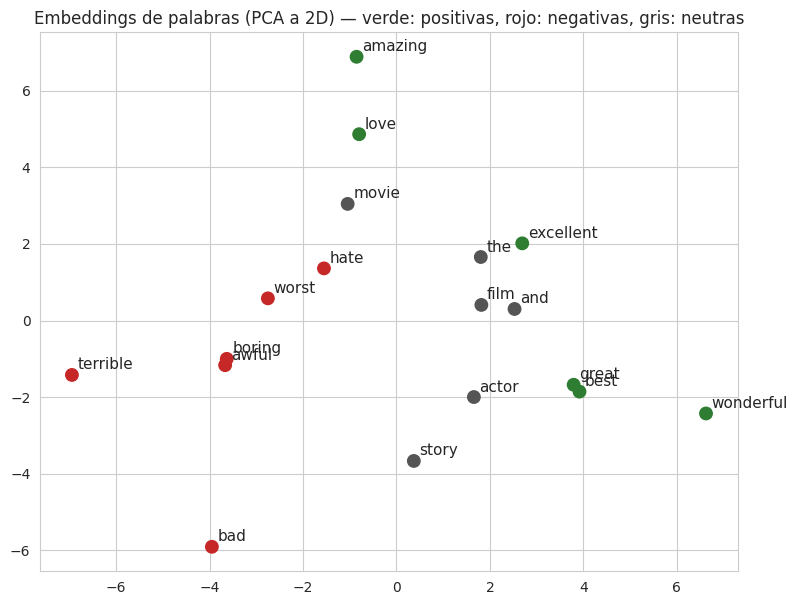

In [29]:
palabras_interes = ["great", "excellent", "amazing", "love", "wonderful", "best",
                     "terrible", "awful", "worst", "hate", "boring", "bad",
                     "movie", "film", "actor", "the", "and", "story"]
indices_interes = [vocabulario[p] for p in palabras_interes if p in vocabulario]
palabras_validas = [p for p in palabras_interes if p in vocabulario]

vectores_embedding = modelo.embedding.weight.detach().cpu().numpy()[indices_interes]
coordenadas_2d = PCA(n_components=2).fit_transform(vectores_embedding)

plt.figure(figsize=(9, 7))
colores = ["#2E7D32" if p in ["great","excellent","amazing","love","wonderful","best"]
           else "#C62828" if p in ["terrible","awful","worst","hate","boring","bad"]
           else "#555555" for p in palabras_validas]
plt.scatter(coordenadas_2d[:, 0], coordenadas_2d[:, 1], c=colores, s=80)
for (x, y), palabra in zip(coordenadas_2d, palabras_validas):
    plt.annotate(palabra, (x, y), fontsize=11, xytext=(4, 4), textcoords="offset points")
plt.title("Embeddings de palabras (PCA a 2D) — verde: positivas, rojo: negativas, gris: neutras")
plt.show()

**Lectura:** si el entrenamiento funcionó bien, las palabras verdes (positivas) tienden a agruparse entre sí, separadas de las rojas (negativas) — el modelo aprendió una representación numérica donde la **cercanía geométrica refleja similitud de sentimiento**, sin que nadie le haya dicho explícitamente qué palabras son sinónimos.

## 9. Probar con una reseña propia

In [31]:
def predecir_sentimiento(texto, modelo, vocabulario, longitud_maxima=LONGITUD_MAXIMA):
    secuencia = texto_a_secuencia(texto, vocabulario, longitud_maxima)
    tensor = torch.tensor([secuencia], dtype=torch.long).to(dispositivo)
    modelo.eval()
    with torch.no_grad():
        probabilidad = torch.sigmoid(modelo(tensor)).item()
    return probabilidad

reseñas_prueba = [
    "This movie was absolutely wonderful, the acting was superb and the story kept me engaged the whole time.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time.",
]
for reseña in reseñas_prueba:
    prob = predecir_sentimiento(reseña, modelo, vocabulario)
    print(f"'{reseña[:60]}...' -> probabilidad positiva: {prob:.3f} "
          f"({'POSITIVA' if prob > 0.5 else 'NEGATIVA'})")

'This movie was absolutely wonderful, the acting was superb a...' -> probabilidad positiva: 1.000 (POSITIVA)
'Terrible film. Boring plot, bad acting, and a complete waste...' -> probabilidad positiva: 0.000 (NEGATIVA)


## 10. Resumen

- El texto se convierte en secuencias numéricas mediante **tokenización + vocabulario + padding**.
- La capa `Embedding` aprende una representación vectorial de cada palabra; la LSTM procesa esa secuencia **respetando el orden**, a diferencia de un modelo de bolsa de palabras.
- El estado oculto final de la LSTM resume toda la reseña en un vector, que una capa `Linear` traduce en una predicción.
- Visualizar los embeddings con PCA es una forma directa de verificar, de forma cualitativa, que el modelo aprendió relaciones semánticas razonables.

Esta misma arquitectura (Embedding + LSTM) es la base conceptual de tareas de NLP mucho más complejas, como la generación de texto o los modelos detrás de los chatbots modernos.
